## Exploratory Data Analysis and Preprocessing
Author: Angela Palacino

### 1. Data description

In [3]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [4]:
# reading the data from url
url = "https://raw.githubusercontent.com/sahanbull/VLE-Dataset/refs/heads/master/VLE_datasets/v1/VLE_12k_dataset_v1.csv"
video_lecture = pd.read_csv(url)

In [5]:
video_lecture.head()

,id,fold,categories,word_count,title_word_count,document_entropy,easiness,fraction_stopword_presence,fraction_stopword_coverage,preposition_rate,...,silent_period_rate,min_engagement,max_engagement,med_engagement,mean_engagement,sd_engagement,num_learners,num_views,avg_star_rating,num_star_ratings
0,1,1,stem,2668,9,7.753995,75.583936,0.553664,0.428135,0.121392,...,0.0,0.030241,1.0,0.502923,1.000000,1.574152,53,1899,-1.0,0
1,2,1,misc,7512,6,8.305269,86.870523,0.584498,0.602446,0.095885,...,0.0,0.008136,1.0,0.011989,0.165811,0.368124,7,1982,-1.0,0
2,3,1,stem,4264,3,7.965583,81.915968,0.605685,0.525994,0.118294,...,0.0,0.009563,1.0,0.041627,0.199148,0.358510,39,3561,5.0,1
3,4,1,stem,2869,9,8.142877,80.148937,0.593664,0.504587,0.122590,...,0.0,0.016787,1.0,0.064989,0.317020,0.662013,36,3030,-1.0,0
4,5,1,misc,4840,9,8.161250,76.907549,0.581637,0.559633,0.130700,...,0.0,0.014288,1.0,0.052154,0.147820,0.263750,25,2864,-1.0,0


In [6]:
video_lecture.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           11548 non-null  int64  
 1   fold                         11548 non-null  int64  
 2   categories                   10459 non-null  object 
 3   word_count                   11548 non-null  int64  
 4   title_word_count             11548 non-null  int64  
 5   document_entropy             11548 non-null  float64
 6   easiness                     11548 non-null  float64
 7   fraction_stopword_presence   11548 non-null  float64
 8   fraction_stopword_coverage   11548 non-null  float64
 9   preposition_rate             11548 non-null  float64
 10  auxiliary_rate               11548 non-null  float64
 11  tobe_verb_rate               11548 non-null  float64
 12  conjugate_rate               11548 non-null  float64
 13  normalization_ra

The original data set cointains 50 columns and 11548 entries. Which include the video id and multiple possible targets.

In [7]:
video_lecture.describe()

,id,fold,word_count,title_word_count,document_entropy,easiness,fraction_stopword_presence,fraction_stopword_coverage,preposition_rate,auxiliary_rate,...,silent_period_rate,min_engagement,max_engagement,med_engagement,mean_engagement,sd_engagement,num_learners,num_views,avg_star_rating,num_star_ratings
count,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,...,11548.000000,1.154800e+04,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000,11548.000000
mean,5774.500000,2.999740,5347.890890,7.705230,7.791438,84.730652,0.612392,0.494730,0.116088,0.015811,...,0.146467,2.241273e-02,0.868883,0.121053,0.258114,0.357608,93.936872,5485.924402,0.012529,0.592310
std,3333.764789,1.414244,5413.868119,3.775191,0.696269,8.330281,0.051470,0.144478,0.018797,0.005465,...,0.172548,4.270257e-02,0.267531,0.169078,0.179828,0.727045,430.090137,14212.555287,2.159751,2.825281
min,1.000000,1.000000,1.000000,1.000000,0.000000,28.210966,0.000000,0.000000,0.000000,0.000000,...,0.000000,3.930000e-07,0.006549,0.002158,0.004200,0.000873,5.000000,659.000000,-1.000000,0.000000
25%,2887.750000,2.000000,2102.000000,5.000000,7.590194,80.345858,0.589435,0.409786,0.106400,0.012369,...,0.000000,5.378474e-03,0.959559,0.030475,0.129673,0.219763,13.000000,2635.750000,-1.000000,0.000000
50%,5774.500000,3.000000,3642.500000,7.000000,7.876202,84.429664,0.613258,0.498471,0.116836,0.015441,...,0.101739,1.123588e-02,1.000000,0.061061,0.217775,0.319408,26.000000,3391.000000,-1.000000,0.000000
75%,8661.250000,4.000000,7188.000000,10.000000,8.164841,88.382702,0.634699,0.608563,0.127139,0.018846,...,0.250981,2.000263e-02,1.000000,0.125955,0.339208,0.413061,56.000000,4822.000000,-1.000000,0.000000
max,11548.000000,5.000000,61653.000000,33.000000,9.278573,122.032000,1.000000,0.813456,0.318182,0.066667,...,1.542962,9.342500e-01,1.000000,1.000000,1.000000,59.963103,22029.000000,452196.000000,5.000000,135.000000


In [ ]:
# Create profiling
video_lecture_profile = ProfileReport(
    video_lecture, title="Video Lecture Engagement Data Profiling"
)
video_lecture_profile.to_file(
    "/home/ange/DS_projects/video_lecture_engagement/reports/video_lecture_engagement.html"
)

From the profiling there are the following findings:

* rank variables: this variables refer to the topics covered in the video, to be used it requires extensive transformation and it is not clear if they will provide useful information. Therefore, they will not be used.
* fold: this variable is uniform, has low variance and offers no information. It will be removed for further analysis.
* type: this variable is a string and has 17 distinct values, each value refers to the type of lecture (lecture, tutorial, invited talk). It has to be encoded to be used for a model.
* categories: This variable has the larges amount of missing values(9.4%) and 3 distinct values. In order to use this variable it needs to be encoded and null values can be put into a no-category variable.
* num_star_ratings: the number of star ratings has 81.6% of zeros, meaning a large percentage of videos don't have a star rating from any user. However, this data would not be available if a video is new.
* avg_star_rating: this value is a possible target for this dataset, however it won't be the target for this project and since it is not available for a new video it will not be used for the models.
* num_learners, num_views: this values are posible target values that can be predicted for this dataset, in this project they will not be the target used and will be removed.
* min_engagement, max_engagement, med_engagement, sd_engagement: These variables are related to the target variable engagement, they will be removed for further analysis.
* mean_engagement: this will be the target variable, initially a video will be classifies as engaging if a learner will watch over 30%.

### 2. Target creation and column filtering

In [8]:
# Current columns in the data set
video_lecture.columns

Index(['id', 'fold', 'categories', 'word_count', 'title_word_count',
       'document_entropy', 'easiness', 'fraction_stopword_presence',
       'fraction_stopword_coverage', 'preposition_rate', 'auxiliary_rate',
       'tobe_verb_rate', 'conjugate_rate', 'normalization_rate',
       'pronoun_rate', 'freshness', 'auth_topic_rank_1_url',
       'auth_topic_rank_1_score', 'auth_topic_rank_2_url',
       'auth_topic_rank_2_score', 'auth_topic_rank_3_url',
       'auth_topic_rank_3_score', 'auth_topic_rank_4_url',
       'auth_topic_rank_4_score', 'auth_topic_rank_5_url',
       'auth_topic_rank_5_score', 'coverage_topic_rank_1_url',
       'coverage_topic_rank_1_score', 'coverage_topic_rank_2_url',
       'coverage_topic_rank_2_score', 'coverage_topic_rank_3_url',
       'coverage_topic_rank_3_score', 'coverage_topic_rank_4_url',
       'coverage_topic_rank_4_score', 'coverage_topic_rank_5_url',
       'coverage_topic_rank_5_score', 'duration', 'speaker_speed', 'has_parts',
       'type',

In [9]:
# Remove other targets and variables that wont be used
drop_columns = [
    "fold",
    "auth_topic_rank_1_url",
    "auth_topic_rank_1_score",
    "auth_topic_rank_2_url",
    "auth_topic_rank_2_score",
    "auth_topic_rank_3_url",
    "auth_topic_rank_3_score",
    "auth_topic_rank_4_url",
    "auth_topic_rank_4_score",
    "auth_topic_rank_5_url",
    "auth_topic_rank_5_score",
    "coverage_topic_rank_1_url",
    "coverage_topic_rank_1_score",
    "coverage_topic_rank_2_url",
    "coverage_topic_rank_2_score",
    "coverage_topic_rank_3_url",
    "coverage_topic_rank_3_score",
    "coverage_topic_rank_4_url",
    "coverage_topic_rank_4_score",
    "coverage_topic_rank_5_url",
    "coverage_topic_rank_5_score",
    "min_engagement",
    "max_engagement",
    "med_engagement",
    "sd_engagement",
    "num_learners",
    "num_views",
    "avg_star_rating",
    "num_star_ratings",
]
video_lecture_final = video_lecture.drop(drop_columns, axis=1)
video_lecture_final.head()

,id,categories,word_count,title_word_count,document_entropy,easiness,fraction_stopword_presence,fraction_stopword_coverage,preposition_rate,auxiliary_rate,...,conjugate_rate,normalization_rate,pronoun_rate,freshness,duration,speaker_speed,has_parts,type,silent_period_rate,mean_engagement
0,1,stem,2668,9,7.753995,75.583936,0.553664,0.428135,0.121392,0.013323,...,0.033309,0.034049,0.089563,16310,890,2.997753,False,vl,0.0,1.000000
1,2,misc,7512,6,8.305269,86.870523,0.584498,0.602446,0.095885,0.014363,...,0.030668,0.018763,0.103002,15410,2850,2.635789,False,vl,0.0,0.165811
2,3,stem,4264,3,7.965583,81.915968,0.605685,0.525994,0.118294,0.019028,...,0.033242,0.030720,0.124255,15680,1680,2.538095,False,vit,0.0,0.199148
3,4,stem,2869,9,8.142877,80.148937,0.593664,0.504587,0.122590,0.023416,...,0.042700,0.016873,0.104339,15610,1270,2.259055,False,vl,0.0,0.317020
4,5,misc,4840,9,8.161250,76.907549,0.581637,0.559633,0.130700,0.021173,...,0.041531,0.023412,0.102606,14920,2000,2.420000,False,vkn,0.0,0.147820


In [10]:
# Create target and set index
video_lecture_final["engagement_30"] = video_lecture_final["mean_engagement"] >= 0.3
video_lecture_final = video_lecture_final.set_index("id")
video_lecture_final = video_lecture_final.drop("mean_engagement", axis=1)

In [11]:
# Columns in the final dataset
video_lecture_final.columns

Index(['categories', 'word_count', 'title_word_count', 'document_entropy',
       'easiness', 'fraction_stopword_presence', 'fraction_stopword_coverage',
       'preposition_rate', 'auxiliary_rate', 'tobe_verb_rate',
       'conjugate_rate', 'normalization_rate', 'pronoun_rate', 'freshness',
       'duration', 'speaker_speed', 'has_parts', 'type', 'silent_period_rate',
       'engagement_30'],
      dtype='object')

### 3. Data exploration
3.1. Numerical Variables

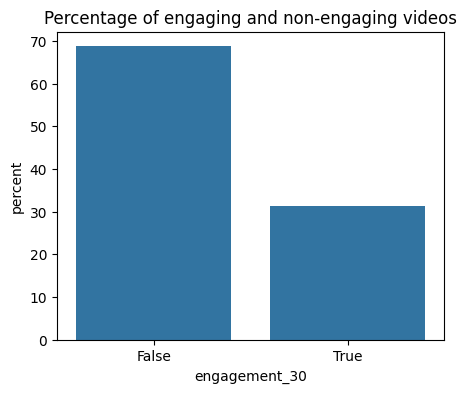

<Figure size 640x480 with 0 Axes>

In [12]:
# Distribution of the target
plt.figure(figsize=(5, 4))
axs = sns.countplot(video_lecture_final, x="engagement_30", stat="percent")
axs.set_title("Percentage of engaging and non-engaging videos")
plt.show()
plt.savefig(
    "/home/ange/DS_projects/video_lecture_engagement/reports/proportion_engagement.png"
)

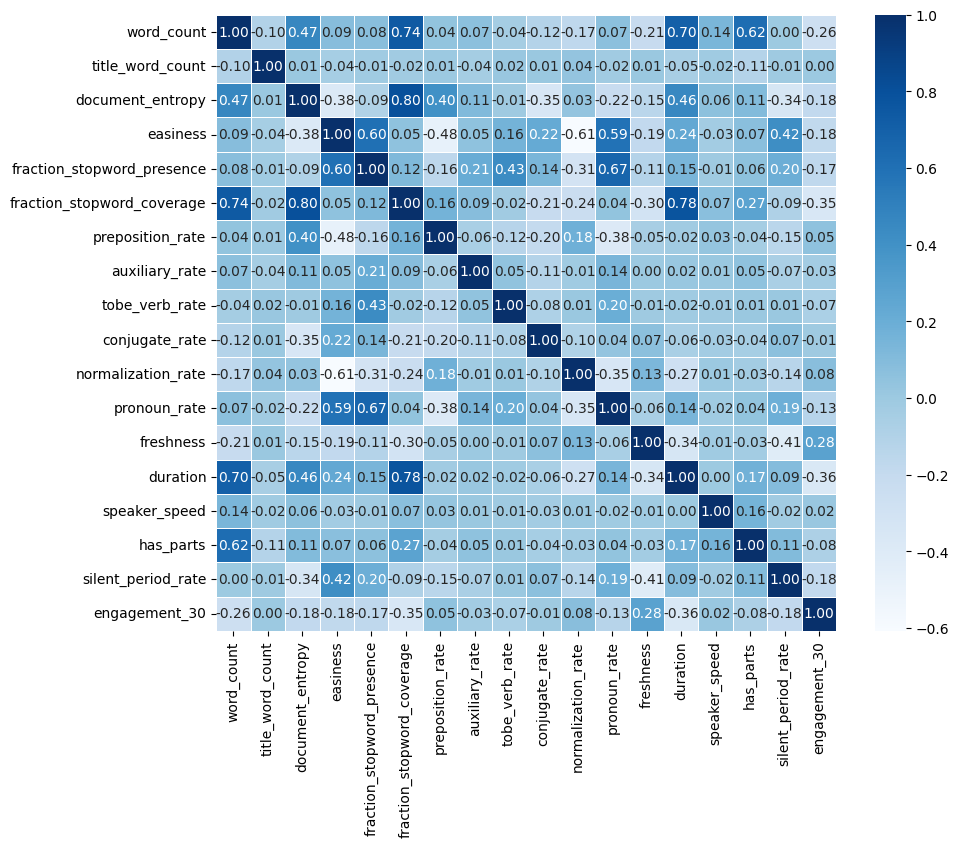

In [13]:
# Correlation of numerical values
corr = video_lecture_final.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.savefig("/home/ange/DS_projects/video_lecture_engagement/reports/correlation.png")
plt.show()

Correlations:

* word_count has a positive correlation with fraction_stopword_coverage,duration and has_parts, it makes sense that the higher word count there will be a higher amount of stopwords and the video will most likely be longer.
* document_entropy has a positive correlation with fraction_stopword_coverage, this indicates that a video with higher randomness also has a larger amount of stopwords.
* easiness has a positive correlation with fraction_stopword_presence and pronoun rate, this suggest videos with a very complex language have less stopwords and pronouns. 
* eassiness and normalization_rate have a negative correlation, this means a video with a complex language(low easiness score) may also have more words ending in -tion, -ment, -ence and -ance.
* preposition_rate and easiness have a negative correlation, videos with complex lenguage may have less prepositions.
* fraction_stopword_presence and pronoun_rate have a positive correlation indicating when there are more stopwords we also find more pronouns.
* fraction_stopword_coverage and duration have a positive correlation suggesting longer videos have a higher coverage of stopwords.


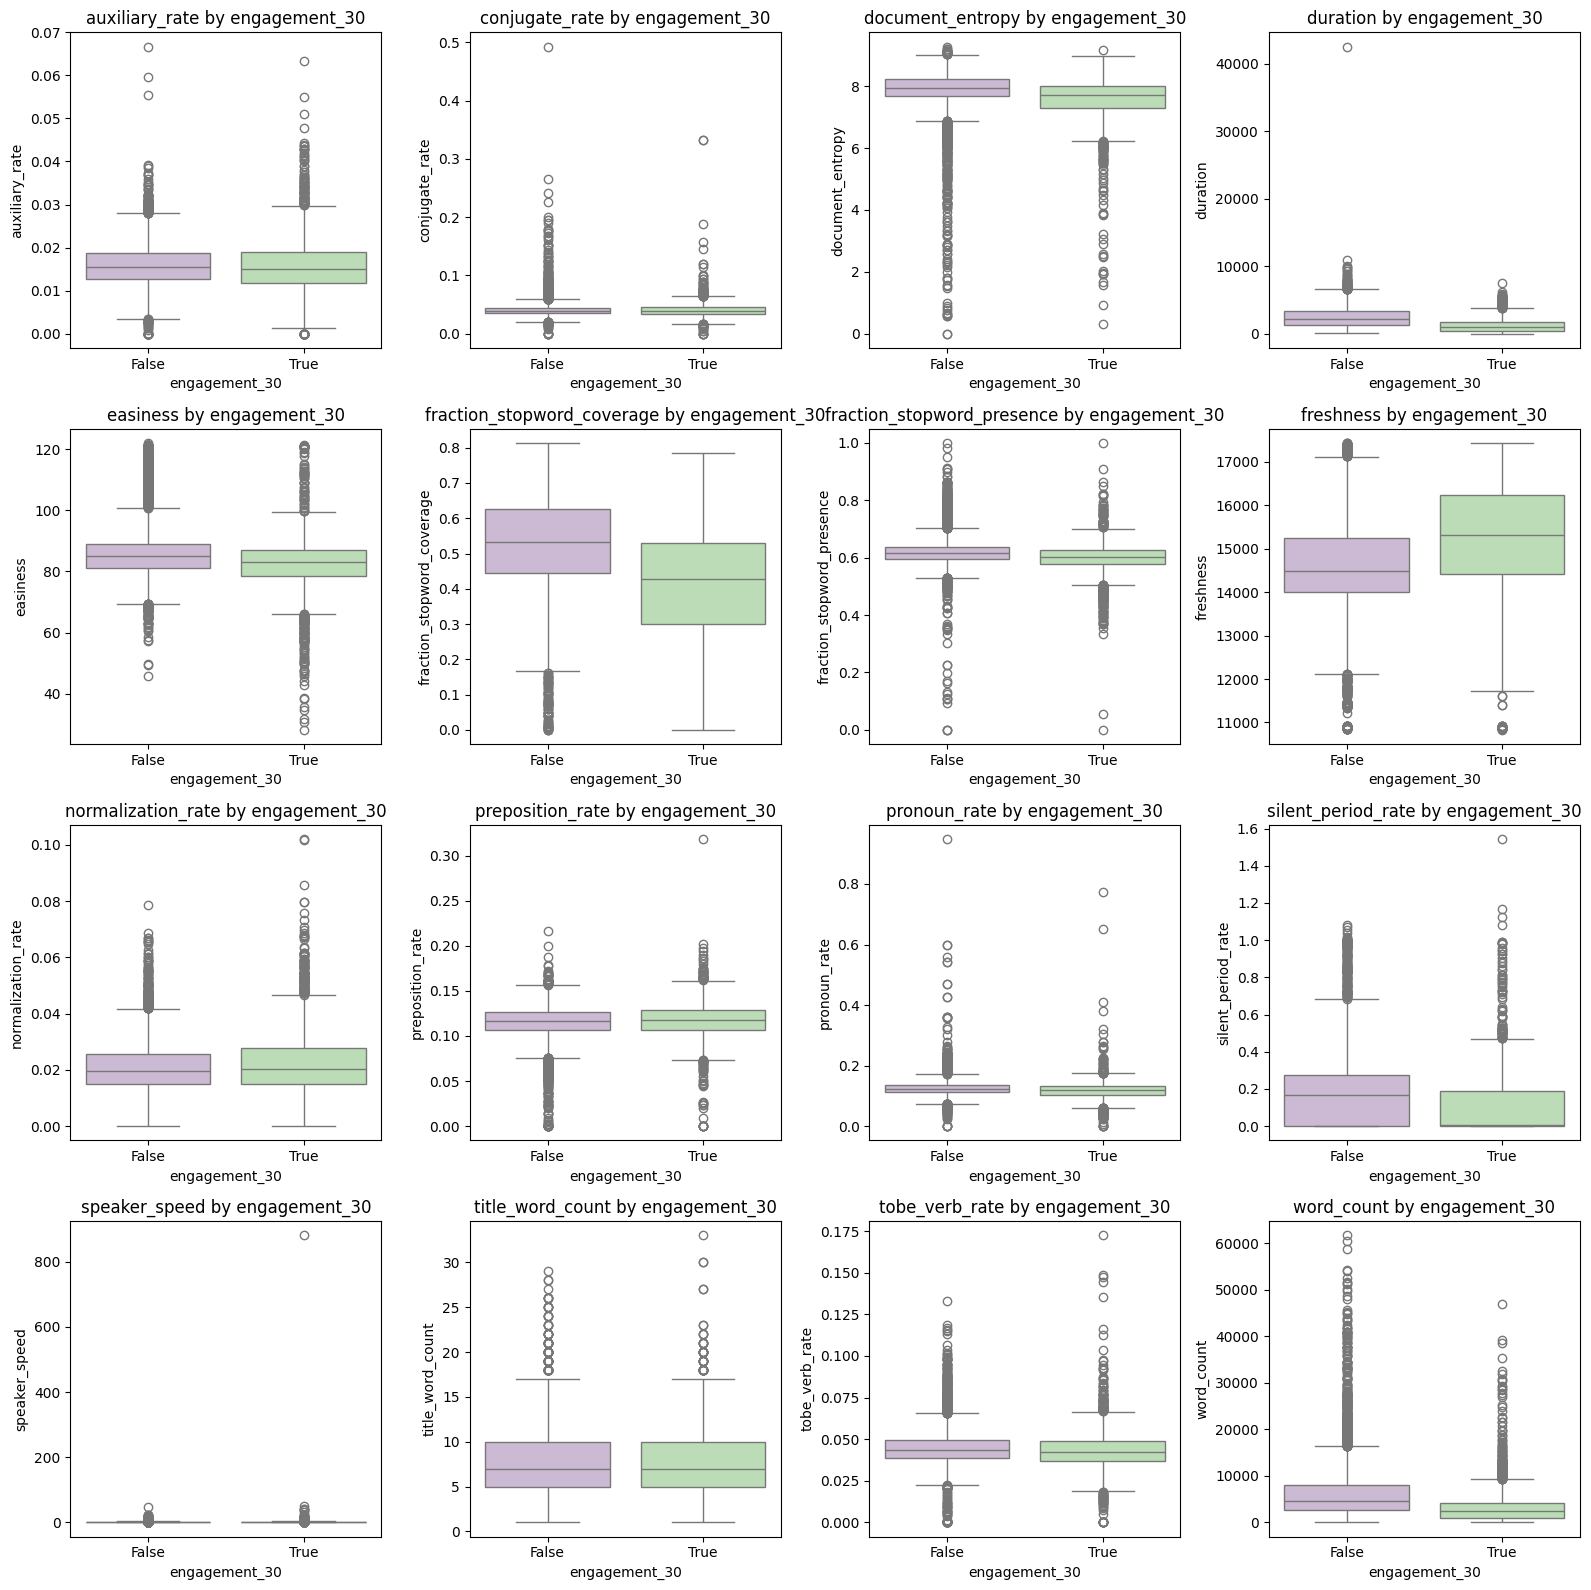

In [14]:
# Create boxplots for each feature

# set target column
target_col = "engagement_30"
# create an array with numerical columns and ignore target column
numerical_cols = video_lecture_final.select_dtypes(
    include=["number"]
).columns.difference([target_col])
# Define the number of rows and columns
n = len(numerical_cols)
cols_per_row = 4  # Number of subplots per row
num_rows = math.ceil(n / cols_per_row)

# Create the plot
fig, axes = plt.subplots(
    num_rows, cols_per_row, figsize=(4 * cols_per_row, 4 * num_rows)
)

# Flatten axes array and trim if needed
axes = axes.flatten()

# Create boxplots
for i, col in enumerate(numerical_cols):
    sns.boxplot(
        x=target_col,
        y=col,
        data=video_lecture_final,
        ax=axes[i],
        palette="PRGn",
        hue=target_col,
    )
    axes[i].set_title(f"{col} by {target_col}")
    axes[i].get_legend().remove()

# Hide any unused axes
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "/home/ange/DS_projects/video_lecture_engagement/reports/feature_boxplots.png"
)
plt.show()

 * The features have very different ranges, this means they have to be normalized to ensure optimal performance in the modelling stage. 
 * The following variables seem to have some relationship with the target: word_count, silent_period_rate, freshness, duration, fraction_stopword_coverage.

3.2. Categorical Variables

In [16]:
non_numerical_cols = video_lecture_final.select_dtypes(
    exclude=["number"]
).columns.difference(["engagement_30"])
non_numerical_cols

Index(['categories', 'has_parts', 'type'], dtype='object')

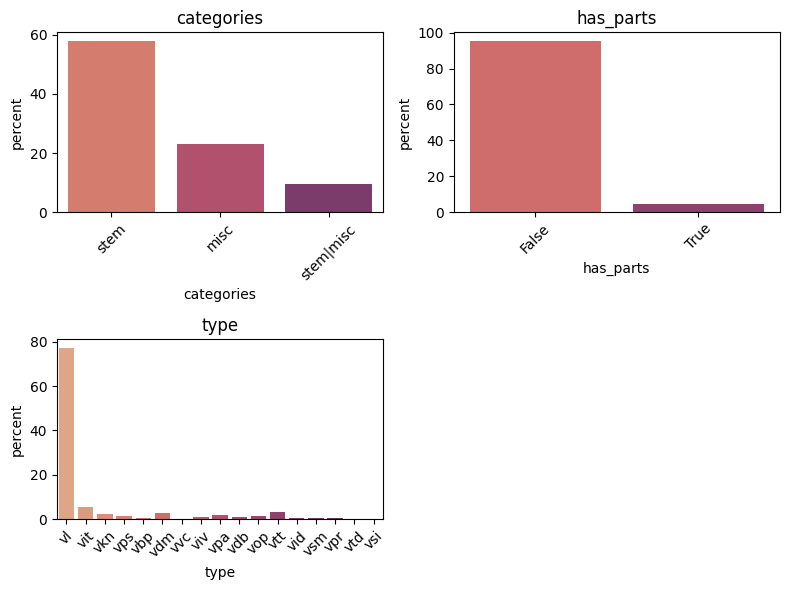

In [ ]:
# number of ocurrances of each
n = len(non_numerical_cols)
cols_per_row = 2  # Number of subplots per row
num_rows = math.ceil(n / cols_per_row)

# Create the plot
fig, axes = plt.subplots(
    num_rows, cols_per_row, figsize=(4 * cols_per_row, 3 * num_rows)
)

# Flatten axes array and trim if needed
axes = axes.flatten()

# Create boxplots
for i, col in enumerate(non_numerical_cols):
    sns.countplot(
        x=col,
        stat="percent",
        data=video_lecture_final,
        ax=axes[i],
        palette="flare",
        hue=col,
        legend=False,
    )
    axes[i].set_title(f"{col}")
    axes[i].tick_params(axis="x", labelrotation=45)
    # axes[i].get_legend().remove()

# Hide any unused axes
for j in range(len(non_numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "/home/ange/DS_projects/video_lecture_engagement/reports/categorical_counts.png"
)
plt.show()

In [52]:
video_lecture_final["type"].value_counts(dropna=False, normalize=True) * 100

type
vl     77.138899
vit     5.264981
vtt     3.108763
vdm     2.727745
vkn     2.372705
vpa     1.792518
vop     1.645307
vps     1.402840
vdb     1.169034
viv     1.047800
vid     0.649463
vpr     0.597506
vbp     0.580187
vsm     0.424316
vvc     0.051957
vtd     0.017319
vsi     0.008660
Name: proportion, dtype: float64

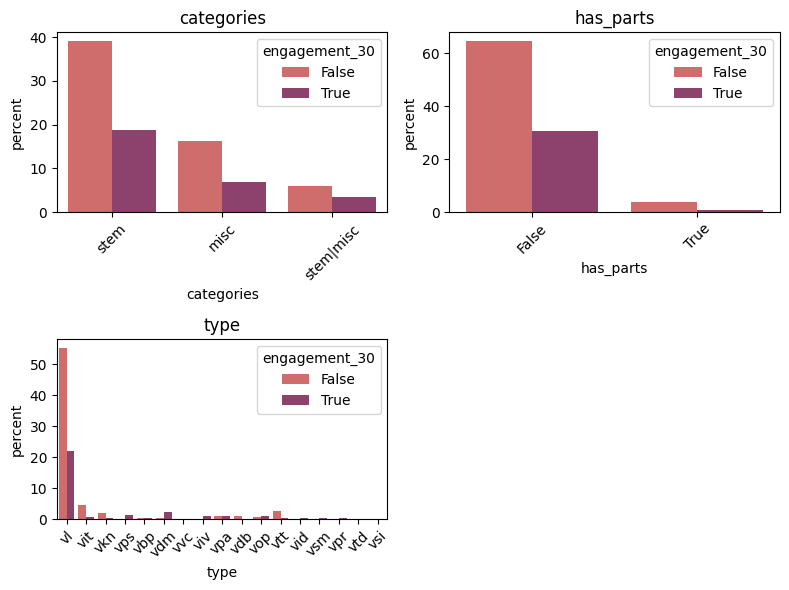

In [48]:
fig, axes = plt.subplots(
    num_rows, cols_per_row, figsize=(4 * cols_per_row, 3 * num_rows)
)
axes = axes.flatten()

for i, col in enumerate(non_numerical_cols):
    sns.countplot(
        x=col,
        hue=target_col,
        data=video_lecture_final,
        ax=axes[i],
        stat="percent",
        palette="flare",
    )
    axes[i].set_title(f"{col}")
    axes[i].tick_params(axis="x", labelrotation=45)
for j in range(len(non_numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(
    "/home/ange/DS_projects/video_lecture_engagement/reports/categorical_balance.png"
)
plt.show()
# This helps see both the balance and frequency of categories and target values.

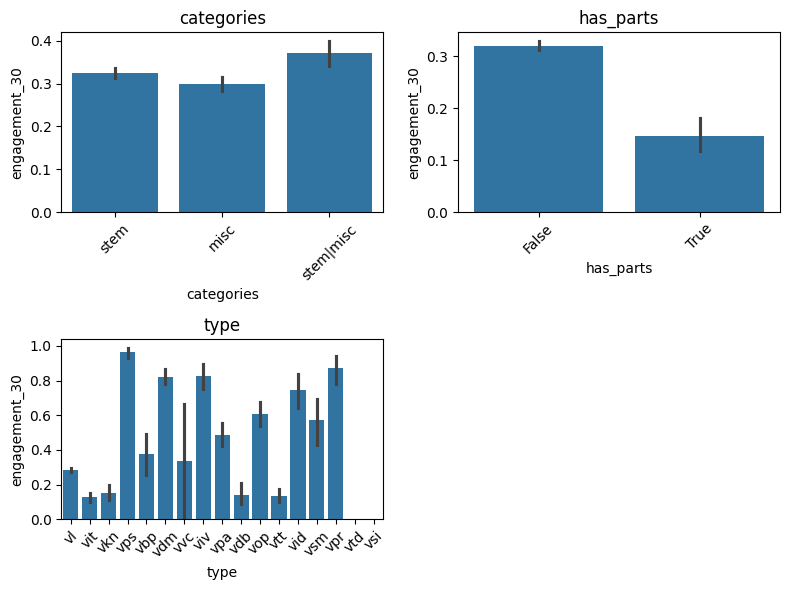

In [49]:
fig, axes = plt.subplots(
    num_rows, cols_per_row, figsize=(4 * cols_per_row, 3 * num_rows)
)
axes = axes.flatten()

for i, col in enumerate(non_numerical_cols):
    sns.barplot(x=col, y=target_col, data=video_lecture_final, ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].tick_params(axis="x", labelrotation=45)
for j in range(len(non_numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig(
    "/home/ange/DS_projects/video_lecture_engagement/reports/categorical_engagement_true.png"
)
plt.show()

* Almost 60% of the videos fall in the category STEM, all categories have around 30% of true engagement values.
* Over 90% of the videos do not have parts, videos that don't have parts have almost double the engagement values.
* Almost 80% of the videos belong to the vl(video lecture) type, this category has around 30% of true engagement values as expected. Although all other types have less than 5% of ocurrences they present an interesting behaviour in the percentage of true engagement. For example, types vps, vdm, viv,vid and vpr have over 80% of true engagement.


### 4. Preprocessing

In [68]:
# Create a copy of the dataframe
video_lecture_processed = video_lecture_final.copy()

In [69]:
# change missing values in categories column to no_category
video_lecture_processed.loc[:, "categories"] = video_lecture_processed[
    "categories"
].fillna("no_category")

In [70]:
# Check for missing values in all columns
video_lecture_processed.isnull().sum()

categories                    0
word_count                    0
title_word_count              0
document_entropy              0
easiness                      0
fraction_stopword_presence    0
fraction_stopword_coverage    0
preposition_rate              0
auxiliary_rate                0
tobe_verb_rate                0
conjugate_rate                0
normalization_rate            0
pronoun_rate                  0
freshness                     0
duration                      0
speaker_speed                 0
has_parts                     0
type                          0
silent_period_rate            0
engagement_30                 0
dtype: int64

In [71]:
categorical_cols = video_lecture_processed.select_dtypes(
    include=["object", "category"]
).columns
numerical_cols = video_lecture_processed.select_dtypes(include=["number"]).columns

In [72]:
# Create dummy variables for categorical features
video_lecture_processed = pd.get_dummies(
    video_lecture_final, columns=categorical_cols, drop_first=True
)
video_lecture_processed.head()

,word_count,title_word_count,document_entropy,easiness,fraction_stopword_presence,fraction_stopword_coverage,preposition_rate,auxiliary_rate,tobe_verb_rate,conjugate_rate,...,type_vl,type_vop,type_vpa,type_vpr,type_vps,type_vsi,type_vsm,type_vtd,type_vtt,type_vvc
id,,,,,,,,,,,,,,,,,,,,,
1,2668,9,7.753995,75.583936,0.553664,0.428135,0.121392,0.013323,0.035159,0.033309,...,True,False,False,False,False,False,False,False,False,False
2,7512,6,8.305269,86.870523,0.584498,0.602446,0.095885,0.014363,0.036749,0.030668,...,True,False,False,False,False,False,False,False,False,False
3,4264,3,7.965583,81.915968,0.605685,0.525994,0.118294,0.019028,0.037827,0.033242,...,False,False,False,False,False,False,False,False,False,False
4,2869,9,8.142877,80.148937,0.593664,0.504587,0.122590,0.023416,0.046832,0.042700,...,True,False,False,False,False,False,False,False,False,False
5,4840,9,8.161250,76.907549,0.581637,0.559633,0.130700,0.021173,0.038884,0.041531,...,False,False,False,False,False,False,False,False,False,False


In [73]:
# Normalize dataframe
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
video_lecture_processed[video_lecture_processed.columns] = scaler.fit_transform(
    video_lecture_processed
)

In [74]:
video_lecture_processed.head()

,word_count,title_word_count,document_entropy,easiness,fraction_stopword_presence,fraction_stopword_coverage,preposition_rate,auxiliary_rate,tobe_verb_rate,conjugate_rate,...,type_vl,type_vop,type_vpa,type_vpr,type_vps,type_vsi,type_vsm,type_vtd,type_vtt,type_vvc
id,,,,,,,,,,,,,,,,,,,,,
1,0.043259,0.25000,0.835688,0.504929,0.553664,0.526316,0.381516,0.199852,0.203923,0.067597,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.121829,0.15625,0.895102,0.625228,0.584498,0.740602,0.301353,0.215450,0.213147,0.062237,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.069146,0.06250,0.858492,0.572420,0.605685,0.646617,0.371782,0.285420,0.219395,0.067461,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.046519,0.25000,0.877600,0.553586,0.593664,0.620301,0.385281,0.351240,0.271625,0.086655,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.078489,0.25000,0.879580,0.519037,0.581637,0.687970,0.410772,0.317590,0.225529,0.084283,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Save data to parquet for next steps
video_lecture_processed.to_parquet(
    "/home/ange/DS_projects/video_lecture_engagement/data/interim/video_lecture_processed.parquet.gzip",
    compression="gzip",
    engine="pyarrow",
)